# Discovery AI: Signature Discovery Practical

In this practical you will apply the signature discovery methods described in the lectures to a dataset to explore the types of signature they produce, and the effects that different choices have. 

## The Dataset

The dataset is a MALDI mass spectrometry image of a sagittal section of a rat cerebellum (part of the brain).

In MALDI (matrix-assisted laser desorption-ionisation) mass spectrometry, a laser is used to ablate material from a section of tissue that has been coated with a special chemical (the matrix) that enables effective energy transfer from the laser to the tissue. This process releases a gaseous plume of ionised molecules from the tissue that can them be analysed. MALDI is typically very good at extracting smaller molecules such as lipids and metabolites, and less good at extracting larger molecules such as proteins.

The gaseous plume of molecules is then aspirated into a mass spectrometer, which accelerates the ionised molecules towards a detector using a careful designed electromagnetic field. The acceleration of the particles is dependent on the ratio of their mass-to-charge ($m/z$) and so the arrival times of the ionised molecules can be used to determine $m/z$. As the plume of gas will contain many different molecules with different $m/z$ values, the measurement produces a *mass spectrum* that shows the abundance of molecules at different $m/z$ values.

This process can be repeated at many different points on a tissue section which allows us to construct a *mass spectrometry image* where at each pixel, we record a mass spectrum that contains detailed information about the chemical composition of the tissue at that location.

The dataset we will be working with comprises $62\times40$ pixels, each of which has a mass spectrum with 4865 $m/z$ values in it. Let's load this in and take a look.

In [1]:
import scipy.io
data = scipy.io.loadmat('signature.mat')
X = data['X'].transpose() 
mz = data['fileInfo'][0][0][8].squeeze()
print(f"Data array X is of size {X.shape}")

Data array X is of size (2480, 4865)


Let's remind our selves of how the data looks. First, let's render an image to make sure we've read everything in correctly. We will display the "total ion count" (TIC image) by summing the spectrum at each pixel

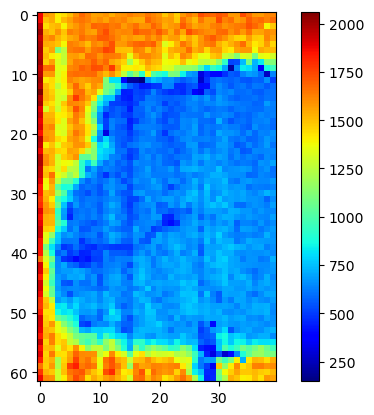

In [2]:
import numpy as np
import matplotlib.pyplot as plt
MSI = np.reshape(X,shape=[62,40,4865])
TICImage = MSI.sum(axis=2)
plt.set_cmap("jet")
plt.imshow(TICImage)
plt.colorbar()


We have something that looks like an image of something which gives us confidence that we have read everything in correctly. Let's now plot a spectrum. Choose something from the middle of image, say row 30, column 20.

[Note that counting starts at 0 so rows are 0 to 61 and columns are 0 to 39.]

Now plot an example spectrum

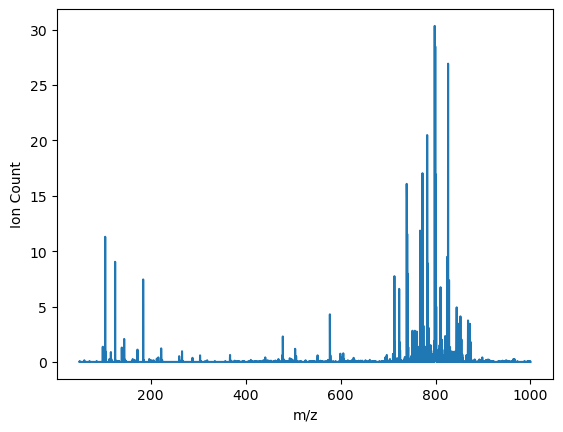

In [3]:
def plotSpectrum(mz,datacube,row, column):
    plt.plot(mz,datacube[row,column,:])
    plt.xlabel('m/z')
    plt.ylabel('Ion Count')
    plt.show()
    return None

plotSpectrum(mz,MSI,20,20)

Finally, plot individual ion images. There are 4865 $m/z$ channels so we can select between 0 and 4864

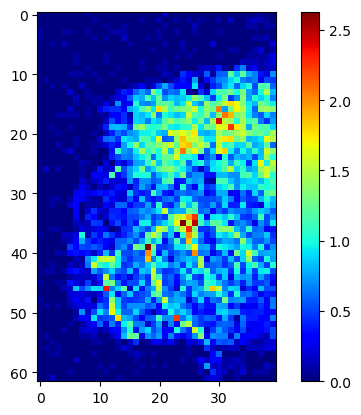

In [4]:
def plotIonImage(datacube, channel):
    plt.imshow(datacube[:,:,channel])
    plt.set_cmap("jet")
    plt.colorbar()
    plt.show()
    return None

plotIonImage(MSI, 4129)


Finally, let's plot a low-d visualisation of this using PCA

Text(0, 0.5, 'PC1')

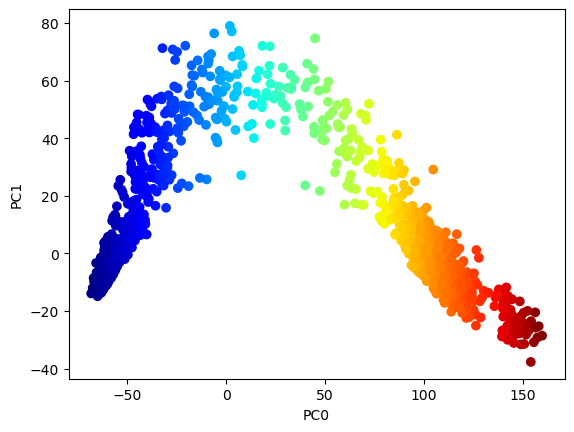

In [5]:
import sklearn.decomposition as decomp
PCA = decomp.PCA()
pc = PCA.fit_transform(X)
plt.scatter(pc[:,0],pc[:,1],c=pc[:,0])
plt.xlabel('PC0')
plt.ylabel('PC1')


## t-Distributed Stochastic Neighbour Embedding

t-distributed Stochastic Neighbour Embedding (tSNE) is a non-linear technique for visualising high dimensional data sets. It uses probabilistic modelling techniques to find a mapping from high to low dimensions that attempts to maintain structure, keeping points that are near to each other close, and points that are far away distant. Unlike LDA, $k$-means, PCA and NMF, tSNE is a nonlinear technique and can "warp" the shape of the data to preserve its structure.

We're going to begin by experimenting with tSNE on a simple dataset of very low resolution (8x8) handwritten digits. The high dimensional space $\mathcal{X}$ in which these sit is 64-dimensional, and we will reduce this to two dimensions. Let;s atrt by loading in the data and plotting a few examples.

There are 1797 digits in the dataset


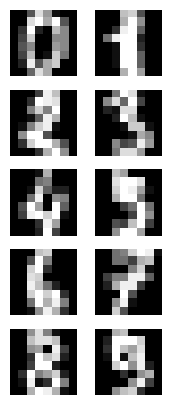

In [6]:
import sklearn.manifold as man
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np
digits,labels = datasets.load_digits(return_X_y=True)
print(f"There are {labels.size} digits in the dataset")

plt.figure(figsize=(2,5))
for index, digit in enumerate(digits[0:10]):
    plt.subplot(5,2,index+1)
    plt.set_cmap('gray')
    plt.imshow(np.reshape(digit,(8,8)))
    plt.axis('off')


Even at this resolution the digits are just about recognisable.

# EXPLORE
* Which digits might you expect to be similar to each other

Let's now run the tSNE algorithm and see how it organises the points

Text(0, 0.5, 'tSNE1')

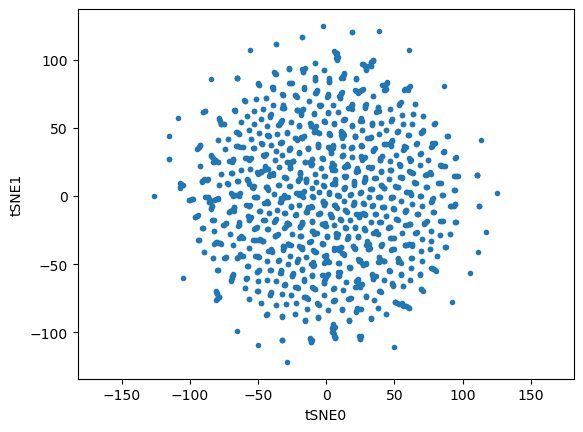

In [7]:
import sklearn.manifold as man
TSNE = man.TSNE(n_components=2, perplexity=1)
XEmbedded = TSNE.fit_transform(digits)
plt.scatter(XEmbedded[:,0],XEmbedded[:,1],marker='.')
plt.axis('equal')
plt.xlabel('tSNE0')
plt.ylabel('tSNE1')

## EXPLORE

* Experiment with the `perplexity` parameter. How does it affect the structure of the embedding? Can you find a setting for the perplexity at which the 2d map looks like it might be a good reflection of the structure (hint - look for structure that is stable across a range of perplexity values).

In this example, we can actually check to see how well tSNE is working, because we have some labels and we know which digit is which

Text(0, 0.5, 'tSNE1')

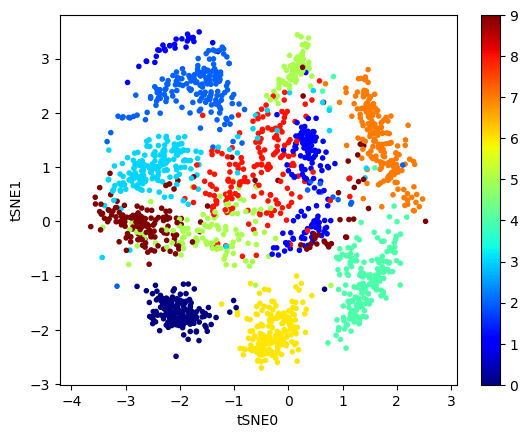

In [34]:
TSNE = man.TSNE(n_components=2, perplexity=1000)
XEmbedded = TSNE.fit_transform(digits)
plt.set_cmap('jet')
plt.scatter(XEmbedded[:,0],XEmbedded[:,1],marker='.',c=labels)
plt.axis('equal')
plt.colorbar()
plt.xlabel('tSNE0')
plt.ylabel('tSNE1')

## EXPLORE

* How does the low-dimensional embedding relate to what we know about the data. Is there a range of values of the peplexity that works best?
* What digits are near to each other in the embedding and which are far apart? Does this match what you would expect?

Let us now apply tSNE to our mass spectrometry imaging dataset. Here, it will be much more difficult to interpret the results, but we have some tricks available to help us.

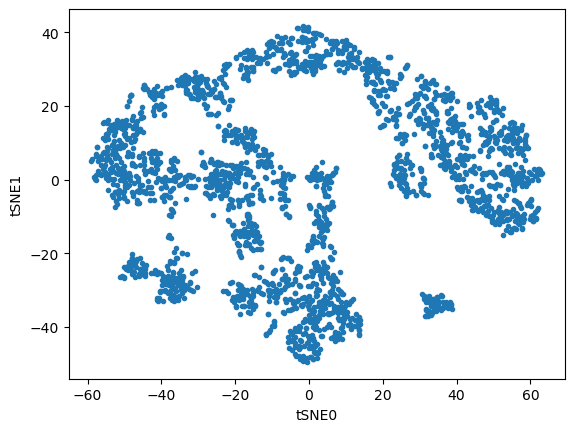

In [9]:
TSNE = man.TSNE(n_components=2, perplexity=30)
XEmbedded = TSNE.fit_transform(X)
plt.plot(XEmbedded[:,0],XEmbedded[:,1],'.')
plt.xlabel('tSNE0')
plt.ylabel('tSNE1')
plt.show()

## EXPLORE
* Can you find a stable mapping that persists over a range of perplexities?
* Can you hypothesise how you think the structure might correspond to what was discivered other techniques (for example, can you identify the off-tissue grouping)?

How can we validate this? It is not perfect, but one possible way is to generate some labels using another technique such as $k$-means. Although this can be criticised in many ways, verifying conclusions with multiple techniques is always good practice.

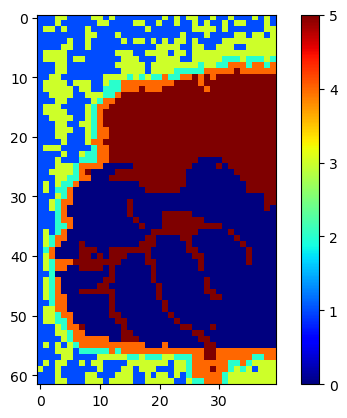

In [35]:
import sklearn.cluster as cluster
# Create a k-means clusterer. This requires us to specify the number of clusters
n_clusters = 6
KM = cluster.KMeans(n_clusters=n_clusters)
# Run the clustering method
KM.fit(X)
# Plot the predictions as an image
plt.imshow(np.reshape(KM.labels_,(62,40)))
plt.colorbar()
plt.show()

In [11]:
print(KM.labels_)
print(labels)

[1 1 1 ... 5 5 5]
[0 1 2 ... 8 9 8]


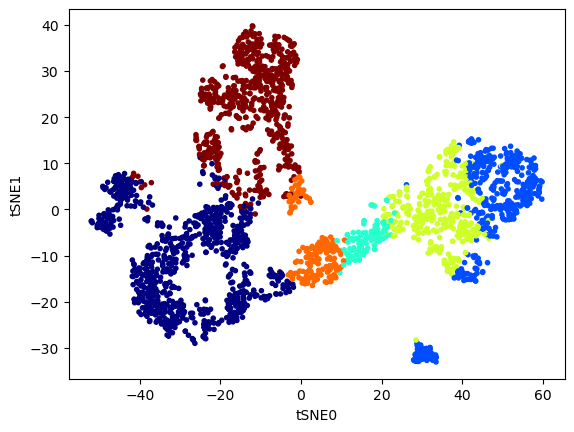

In [36]:
TSNE = man.TSNE(n_components=2, perplexity=50)
XEmbedded = TSNE.fit_transform(X)
plt.scatter(XEmbedded[:,0],XEmbedded[:,1],marker='.',c=KM.labels_)
plt.xlabel('tSNE0')
plt.ylabel('tSNE1')
plt.show()

## EXPLORE
* How well do the two techniques match up? Are there parameter values for $k$ and perplexity that match particularly well?

## Variational Autoencoders

Let us now explore the use of variational autoencoder to identify structure in a dataset.

Unlike tSNE, there is no standard implementation of a VAE that we can pull in from a library so we are going to have to write our own, and this requires quite a lot of code. Much of this is "boilerplate" code that a LLM can help to generate (this code was generated with help from ChatGPT). The specific models that are being implemented were described in the lecture.

We start with some library imports

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

We now define a function that selects which device we want to compute on. This enables us to select an NVIDIA GPU if one is available. If you have one, you will want to use it as things will be *much* faster with it.

In [20]:
def get_device(use_gpu: bool):
    if use_gpu and torch.cuda.is_available():
        print("using cuda")
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        print("using mps")
        return torch.device("mps")
    else:
        print ("using cpu")
        return torch.device("cpu")


Next, we define the standard VAE loss function. There are two "standard" choices, binary cross-entropy(`bce`) and mean-square error (`mse`)

In [21]:
def vae_loss(recon_x, x, mu, logvar, recon_type="mse"):
    if recon_type == "bce":
        recon = F.binary_cross_entropy(recon_x, x, reduction="sum")
    else:
        recon = F.mse_loss(recon_x, x, reduction="sum")

    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

We now define two type of model. The first of these uses an encoder and decoder that are structured as multi-layer perceptrons. We'll specify the hyperparameters (number/size of layers) of these models when we actually create them

In [22]:
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        self.net = nn.Sequential(*layers)
        self.mu = nn.Linear(prev, latent_dim)
        self.logvar = nn.Linear(prev, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


class MLPDecoder(nn.Module):
    def __init__(self, output_dim, hidden_dims, latent_dim):
        super().__init__()

        layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class MLPVAE(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.encoder = MLPEncoder(input_dim, hidden_dims, latent_dim)
        self.decoder = MLPDecoder(input_dim, hidden_dims, latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar



Now we define the second type of model which uses 1d convolutional layers. Here the layers are more easily specified in the model definition.

In [23]:
class CNNEncoder(nn.Module):
    def __init__(self, input_length, latent_dim):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 256, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        dummy = torch.zeros(1, 1, input_length)
        conv_out = self.conv(dummy).numel()

        self.flatten_dim = conv_out
        self.mu = nn.Linear(conv_out, latent_dim)
        self.logvar = nn.Linear(conv_out, latent_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.conv(x)
        h = h.flatten(start_dim=1)
        return self.mu(h), self.logvar(h)


class CNNDecoder(nn.Module):
    def __init__(self, input_length, flatten_dim, latent_dim):
        super().__init__()

        self.input_length = input_length
        self.fc = nn.Linear(latent_dim, flatten_dim)

        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, 3, stride=2, padding=1, output_padding=1),
        )

        self.final = nn.Linear(self._get_output_size(), input_length)

    def _get_output_size(self):
        dummy = torch.zeros(1, 256, 152)
        return self.deconv(dummy).flatten(1).shape[1]

    def forward(self, z):
        h = self.fc(z)
        h = h.view(z.size(0), 256, -1)
        h = self.deconv(h)
        h = h.flatten(start_dim=1)
        return self.final(h)


class CNNVAE(nn.Module):
    def __init__(self, input_length, latent_dim):
        super().__init__()
        self.encoder = CNNEncoder(input_length, latent_dim)
        self.decoder = CNNDecoder(input_length, self.encoder.flatten_dim, latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar



We now define how the model is trained.

In [24]:
def train(model, dataloader, optimizer, device, epochs, recon_type):
    model.train()

    for epoch in range(epochs):
        total = 0
        for (x,) in dataloader:
            x = x.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, recon_type)
            loss.backward()
            optimizer.step()

            total += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss {total/len(dataloader.dataset):.4f}")

This is now enough for us to train the model. Let's do that now (warning - this could take up to 10-15 minutes):

In [25]:
# Set up the compute device - if you have a GPU set this to True
device = get_device(use_gpu=True)



# Set up the parameters
latent_dim = 5          # number of dimensions in the latent space
modeltype = "mlp"       # mlp or cnn
epochs = 100            # max number of times the network sees the data during training
batch_size = 32         # The amount of date the model sees at each gradient update
lr = 1e-4               # Target value for the loss
recon_loss = "mse"      # type of loss to use - mse or bce

# Create a Pytorch dataset and dataloader
X = X.astype(np.float32)
dataset = TensorDataset(torch.tensor(X))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Create the model depending on what type has been selected
if modeltype == "mlp":
    hidden = [2048, 1024, 512, 256, 128]  # five hidden layers
    model = MLPVAE(X.shape[1], hidden, latent_dim)
else:
    model = CNNVAE(X.shape[1], latent_dim)

# Send the model to the compute device
model.to(device)

# set the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)     

# run the training loop
train(model, loader, optimizer, device, epochs, recon_loss)

# save the model state so we can load the parameters in without retraining
torch.save(model.state_dict(), "vae-mlp.pt")

using mps
Epoch 1/100 | Loss 8402.8078
Epoch 2/100 | Loss 4748.9402
Epoch 3/100 | Loss 1183.0125
Epoch 4/100 | Loss 892.8890
Epoch 5/100 | Loss 774.2789
Epoch 6/100 | Loss 610.4180
Epoch 7/100 | Loss 547.3854
Epoch 8/100 | Loss 520.0093
Epoch 9/100 | Loss 500.8188
Epoch 10/100 | Loss 483.1826
Epoch 11/100 | Loss 459.2178
Epoch 12/100 | Loss 427.0687
Epoch 13/100 | Loss 404.8509
Epoch 14/100 | Loss 393.6691
Epoch 15/100 | Loss 386.9755
Epoch 16/100 | Loss 391.5833
Epoch 17/100 | Loss 383.0378
Epoch 18/100 | Loss 380.2077
Epoch 19/100 | Loss 377.0986
Epoch 20/100 | Loss 372.0797
Epoch 21/100 | Loss 370.8936
Epoch 22/100 | Loss 370.6871
Epoch 23/100 | Loss 371.4431
Epoch 24/100 | Loss 365.5602
Epoch 25/100 | Loss 363.8886
Epoch 26/100 | Loss 368.0449
Epoch 27/100 | Loss 367.4308
Epoch 28/100 | Loss 357.9669
Epoch 29/100 | Loss 360.9970
Epoch 30/100 | Loss 355.7647
Epoch 31/100 | Loss 358.2327
Epoch 32/100 | Loss 354.7427
Epoch 33/100 | Loss 349.8251
Epoch 34/100 | Loss 345.2248
Epoch 35/1

Let's see how well the VAE is able to reconstruct its inputs

In [26]:
@torch.no_grad()
def reconstruct(model, x, device):
    model.eval()
    x = torch.tensor(x, dtype=torch.float32).to(device)
    recon, _, _ = model(x)
    return recon.cpu().numpy()

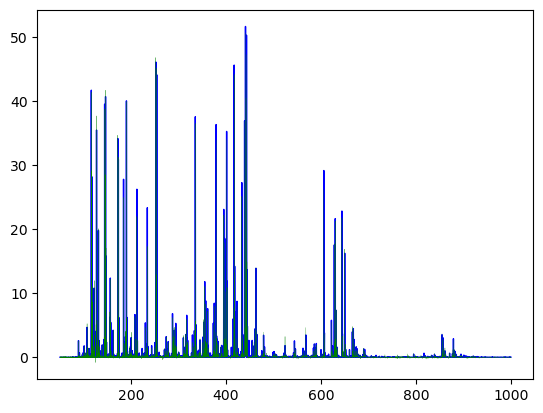

In [27]:
# Select a datapoint
x = X[1000,:]

y = reconstruct(model, x, device)
plt.plot(mz,x,'b',linewidth=1.0)
plt.plot(mz,y,'g',linewidth=0.2)

## EXPLORE
* How well does the VAE reconstruct the input?
* If there are differences, what is the nature of them?
* Does it do equally well for all "classes" of input?

One of the key features of VAEs is that they include a proper generative model. If we select a random point from the latent space, and feed this in to the decoder, it should produce a sample that is approximately from the input distribution.

In [37]:
@torch.no_grad()
def sample_latent(model, n, latent_dim, device):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)
    return model.decoder(z).cpu().numpy()

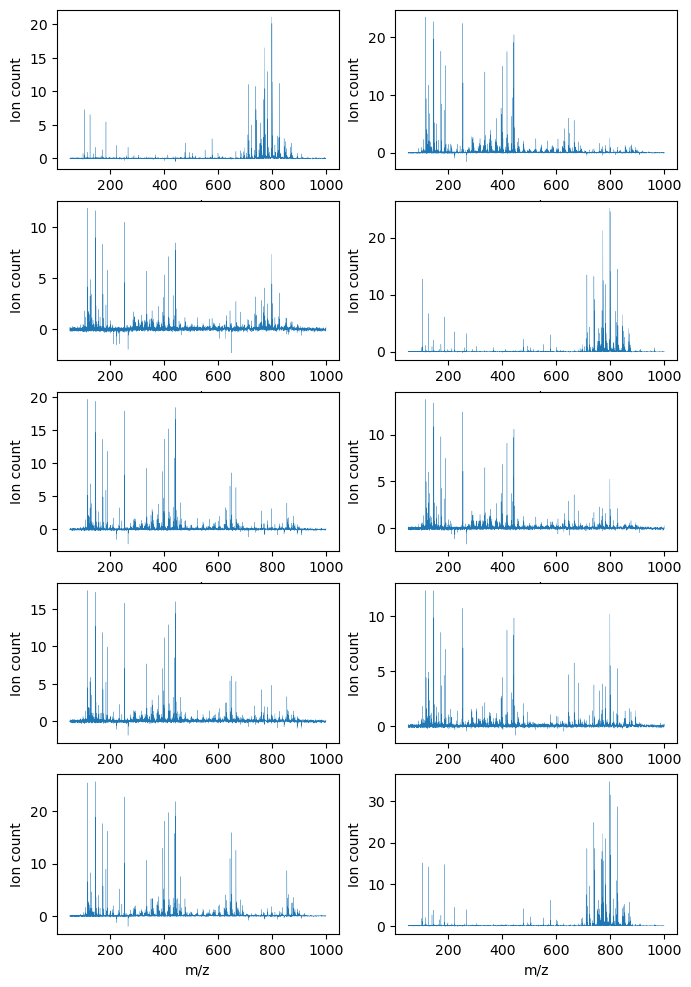

In [38]:
# Draw ten random samples from the latent space and decode them
sample = sample_latent(model, 10, latent_dim, device)

plt.figure(figsize=[8,12])
for index, x in enumerate(sample):
    plt.subplot(5,2,index+1)
    plt.plot(mz,x,linewidth=0.2)
    plt.xlabel("m/z")
    plt.ylabel("Ion count")

## EXPLORE
* Are there obvious correspondences between these samples and the decompositions that we have previously identified?

## Visualising the latent space

Let us now take a look at the latent space in a bit more detail. Let us recall that the latent space of the VAE is 5d. We are going to put our data through the VAE, extract the coordinate of each point in the 6d latent space, and then plot, first using PCA and then tSNE.

First we extract the coordinates $z$ in the latent space:

In [39]:
## Extract latent vectors

@torch.no_grad()
def get_latent_embeddings(model, X, device, batch_size=256):
    model.eval()

    X_tensor = torch.tensor(X, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(X_tensor, batch_size=batch_size)

    latents = []

    for batch in loader:
        batch = batch.to(device)
        z, _ = model.encoder(batch)
        latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

Now we reduce the dimension to 2 using either PCA or tsne 

In [40]:
# Reduce dimension and plot
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_latent_space(Z, labels=None, method="pca", save_path=None):
    """
    Z: latent vectors (N, latent_dim)
    labels: optional class labels (N,)
    method: pca | tsne
    """

    if method == "pca":
        reducer = PCA(n_components=2)

    elif method == "tsne":
        reducer = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate="auto",
            init="pca"
        )
    else:
        raise ValueError("method must be pca or tsne")

    Z2 = reducer.fit_transform(Z)

    plt.figure(figsize=(7, 6))

    if labels is None:
        plt.scatter(Z2[:, 0], Z2[:, 1], s=10, alpha=0.7)
    else:
        scatter = plt.scatter(
            Z2[:, 0],
            Z2[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.8
        )
        plt.colorbar(scatter)

    plt.title(f"Latent space ({method.upper()})")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")



Run the visualisation and plot the points coloured by the labels we obtained from k-means

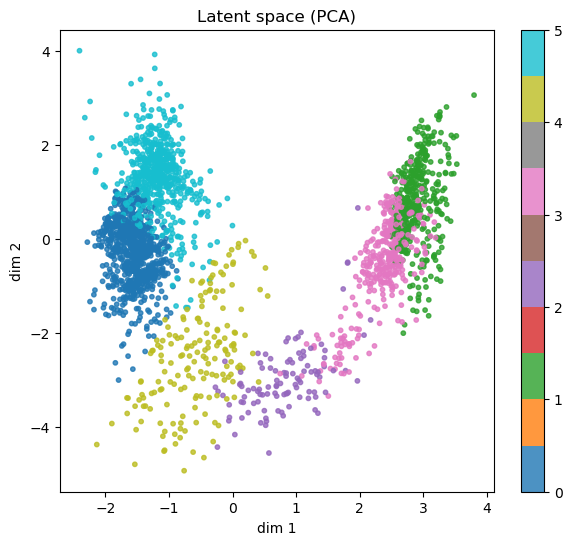

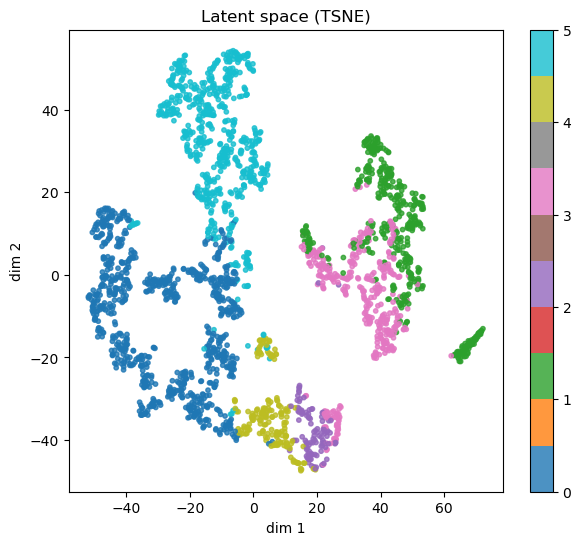

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load trained model
model = MLPVAE(4865, [2048,1024,512,256,128], 5)
model.load_state_dict(torch.load("vae-mlp.pt", map_location=device))
model.to(device)

# get latent vectors
Z = get_latent_embeddings(model, X, device)

# visualise
plot_latent_space(Z, labels=KM.labels_, method="pca")
plot_latent_space(Z, labels=KM.labels_, method="tsne")


## EXPLORE
- How well does the latent space preserce the structure of the data?
- Particularly in tSNE, have the relationships between the groups changed?

Let's also visualise the latent space by plotting the dimensions against each other, also adding a histogram to visually the density of the points.

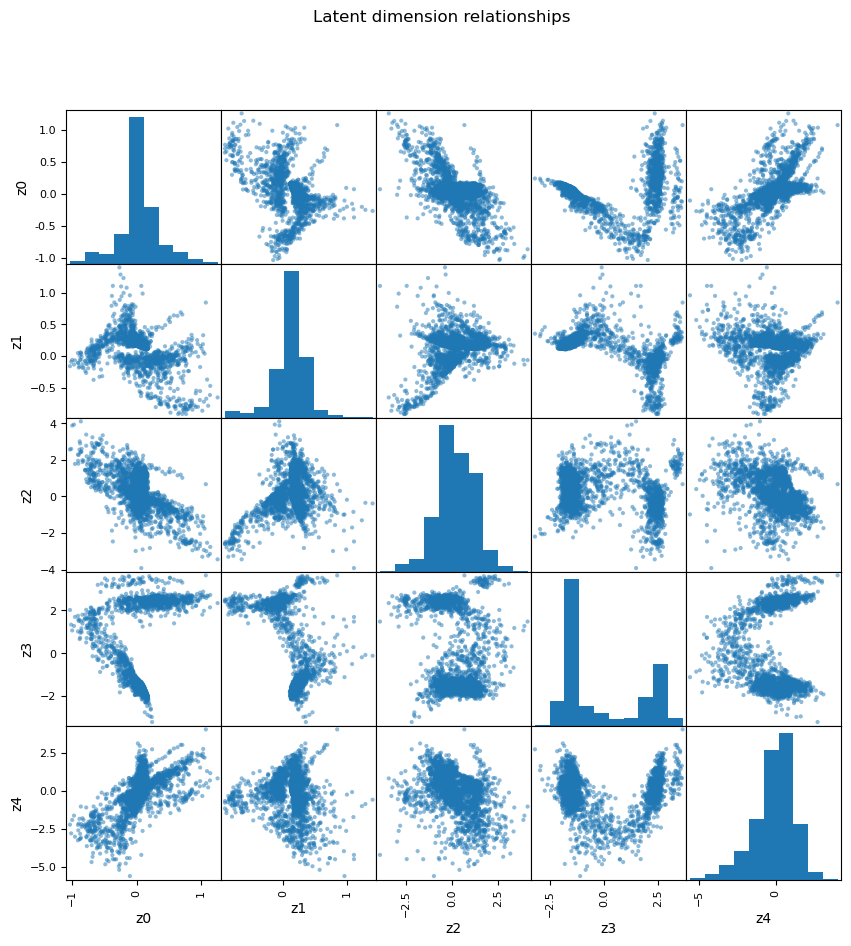

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

def plot_latent_pairs(Z):
    df = pd.DataFrame(Z, columns=[f"z{i}" for i in range(Z.shape[1])])
    scatter_matrix(df, figsize=(10, 10), diagonal="hist")
    plt.suptitle("Latent dimension relationships")
    plt.show()


plot_latent_pairs(Z)

## EXPLORE
- The aim of the VAE is to learn a latent space that is normally distributed. How well has this been done?

Finally, lets "walk around" the latent space. By changing the value of `dim` we can move across the latent space along one of its five axes, keeping the other dimensions fixed, generating samples as we move.

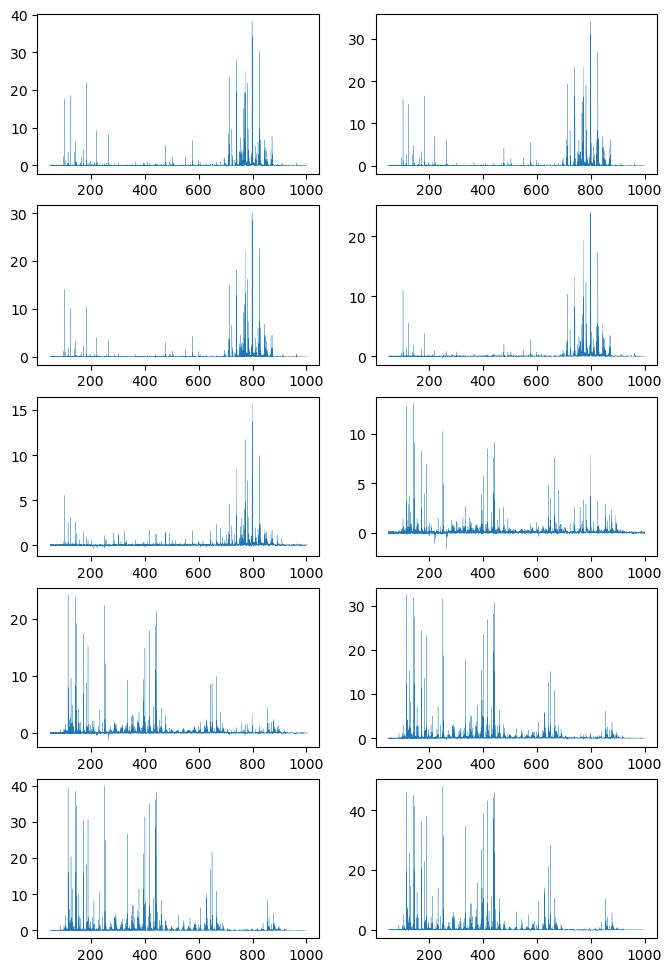

In [46]:
@torch.no_grad()
def latent_traversal(model, device, dim=0, steps=10, value_range=(-3, 3)):
    model.eval()

    zs = torch.zeros(steps, 5).to(device)
    values = torch.linspace(*value_range, steps).to(device)
    zs[:, dim] = values

    outputs = model.decoder(zs).cpu().numpy()
    return outputs

traversed = latent_traversal(model,device, dim=3)
plt.figure(figsize=[8,12])
for i,v in enumerate(traversed):
    plt.subplot(5,2,i+1)
    plt.plot(mz,v,linewidth=0.2)

## EXPLORE

- How do the samples change as you traverse each dimension?
- Can you relate to the data, for example, can you identify the region in the latent space that represents "off-tissue"?